# Survey Diagnostics Report

---

*Runs Before*: None

*Runs After*: ``fov.ipynb``, ``main.ipynb``

This notebook computes summary diagnostics for the survey plan produced by ``main.ipynb``,
characterizing how well it meets the mission's coverage and cadence requirements. It:

1. Breaks down how mission time was spent -- observing, slewing, and downlinking -- over the
   course of the plan.
2. Computes the fraction (and area) of sky visited a given number of times, separately for each
   candidate FOV shape (the bounding rectangle, the inscribed circle, and the true, roll-angle-
   dependent chip footprint), to check that the delivered coverage matches what was assumed when
   the sky was tiled (see ``fov.ipynb`` and ``skygrid.ipynb``).
3. Tracks the completeness of each constituent survey (``ALL_SKY_BASE``, ``LMLZ_WIDE``,
   ``LMLZ_DEEP``, ``LMLZ_DEEP_POINTS``, ``MC``) -- both its share of all delivered visits and how
   its delivered-vs-required completion has evolved over time.
4. Computes cadence diagnostics -- a histogram of pairwise observation separations and a
   transient pair-count sensitivity curve -- using the true chip footprint, since that is what
   actually determines re-observation.
5. Computes the distribution of slew duration and angle, broken out separately for all slews,
   ordinary observing slews, and slews adjacent to a downlink (unconstrained, since the
   instrument returns to a fixed downlink orientation).

## Settings / Configuration


In [1]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [2]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import numpy as np
from astropy import units as u
from astropy.coordinates import ICRS
from astropy.table import QTable
from astropy_healpix import HEALPix
from ligo.skymap import plot  # noqa: F401
from m4opt.fov import footprint_healpix
from m4opt.missions import uvex as mission
from matplotlib import colors
from matplotlib import pyplot as plt
from regions import Regions
from tqdm.auto import tqdm

/Users/ediggins/Dev/uvex-scheduler/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configuration Settings

A number of configuration settings are available in this notebook. Please configure the options
below to your liking. The default settings are recommended for most users.


In [3]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- CORE SETTINGS --- #
# OUTPUT_PATH: Directory shared with ``fov.ipynb`` and ``main.ipynb``. This notebook reads their
#              outputs from here and writes its diagnostic plots back into it.
OUTPUT_PATH = Path("../preliminary_survey")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# --- FOV SETTINGS --- #
# Paths to the DS9 region files written by ``fov.ipynb``. If ``None``, they are looked up in
# ``OUTPUT_PATH`` (i.e. wherever ``fov.ipynb`` wrote them). The true chip footprint is not
# included here because it is read directly from the ``mission`` object below, to guarantee a
# single point of truth (see ``fov.ipynb``).
BOUNDING_RECTANGLE_FOV_PATH = None
INSCRIBED_CIRCLE_FOV_PATH = None

# --- SURVEY PLAN SETTINGS --- #
# Paths to the survey plan and block tables written by ``main.ipynb``/``skyblocks.ipynb``. If
# ``None``, they are looked up in ``OUTPUT_PATH``.
PLAN_FILE_PATH = None
BLOCKS_FILE_PATH = None

# --- COVERAGE SETTINGS --- #
# HEALPix resolution used to bin the sky when computing the coverage statistics below. Higher
# NSIDE gives finer spatial resolution at the cost of more memory and compute time.
HEALPIX_NSIDE = 2048

# --- CADENCE SETTINGS --- #
# HEALPix resolution for the cadence diagnostics below -- deliberately much coarser than
# HEALPIX_NSIDE above. Cadence statistics are computed per pixel via an all-pairs scan *within*
# that pixel's own visits, so a coarse grid keeps each pixel's visit count (and hence runtime)
# manageable even for a multi-year, many-pass survey.
CADENCE_HEALPIX_NSIDE = 128

# Number of log-spaced bins for the pairwise-separation histogram; the bin range itself is set
# from the survey's own minimum and maximum pairwise separations (see the "Cadence pair-
# separation histogram" section below), not hardcoded here.
CADENCE_N_HISTOGRAM_BINS = 40

# Characteristic transient timescales to evaluate the pair-count sensitivity curve over,
# spanning roughly a day (fast transients) to the length of the baseline all-sky survey.
CADENCE_MIN_TIMESCALE = 0.25 * u.day
CADENCE_MAX_TIMESCALE = 730 * u.day
CADENCE_N_TIMESCALES = 50

# A pair of visits separated by dt "qualifies" for a timescale T if
# CADENCE_MINIMUM_FACTOR * T <= dt <= CADENCE_MAXIMUM_FACTOR * T.
CADENCE_MINIMUM_FACTOR = 0.5
CADENCE_MAXIMUM_FACTOR = 2.0

# --- VISUALIZATION SETTINGS --- #
# Controls for which diagnostic plots this notebook saves to ``OUTPUT_PATH``.
SAVE_TIME_USAGE_PLOT = True
SAVE_WEEKLY_USAGE_PLOT = True
SAVE_COVERAGE_PLOTS = True
SAVE_COMPLETENESS_PLOT = True
SAVE_CADENCE_PLOTS = True
SAVE_SLEW_DISTRIBUTION_PLOT = True

## Load FOV Files, Survey Plan, and Blocks

Load the FOV region files produced by ``fov.ipynb``, the survey plan produced by ``main.ipynb``,
and the block table produced by ``skyblocks.ipynb`` (needed below to attribute each observation
to a constituent survey).


In [4]:
# ========================================= #
# Load FOV Files, Survey Plan, and Blocks   #
# ========================================= #
BOUNDING_RECTANGLE_FOV_PATH = (
    OUTPUT_PATH / "bounding-rectangle.ds9"
    if BOUNDING_RECTANGLE_FOV_PATH is None
    else Path(BOUNDING_RECTANGLE_FOV_PATH)
)
INSCRIBED_CIRCLE_FOV_PATH = (
    OUTPUT_PATH / "inscribed-circle.ds9"
    if INSCRIBED_CIRCLE_FOV_PATH is None
    else Path(INSCRIBED_CIRCLE_FOV_PATH)
)
PLAN_FILE_PATH = (
    OUTPUT_PATH / "initial-survey.ecsv"
    if PLAN_FILE_PATH is None
    else Path(PLAN_FILE_PATH)
)
BLOCKS_FILE_PATH = (
    OUTPUT_PATH / "blocks.ecsv" if BLOCKS_FILE_PATH is None else Path(BLOCKS_FILE_PATH)
)

for _path, _source_notebook in (
    (BOUNDING_RECTANGLE_FOV_PATH, "fov.ipynb"),
    (INSCRIBED_CIRCLE_FOV_PATH, "fov.ipynb"),
    (PLAN_FILE_PATH, "main.ipynb"),
    (BLOCKS_FILE_PATH, "skyblocks.ipynb"),
):
    if not _path.exists():
        raise FileNotFoundError(
            f"File not found at {_path}. Run {_source_notebook} first (writing to the same "
            "OUTPUT_PATH) to generate it."
        )

(BOUNDING_RECTANGLE_FOV,) = Regions.read(str(BOUNDING_RECTANGLE_FOV_PATH))
(INSCRIBED_CIRCLE_FOV,) = Regions.read(str(INSCRIBED_CIRCLE_FOV_PATH))
PLAN = QTable.read(PLAN_FILE_PATH)
OBS = PLAN[PLAN["action"] == "observe"]
BLOCKS = QTable.read(BLOCKS_FILE_PATH)

## Time Usage

---

Break down how the mission's available time was spent: observing, slewing, and downlinking come
directly from the plan's ``total_time`` metadata (written by ``main.ipynb``); its single
``slack`` figure is further split below into **block slack** and **empty blocks**, since the two
have very different implications for survey completeness.

Every idle gap in the plan falls immediately before a ``downlink`` row (each of which starts one
matched block-visit's slot) -- a block's own dwells and slews are always packed back-to-back by
construction, so there is never idle time in the *middle* of one. That means every gap splits
cleanly into two physically distinct pieces:

- **Block slack**: the block finished observing all of its own fields before its own slot's
  nominal end. This is a mismatch between how big the block is and the (fixed) slot width --
  e.g. ``skyblocks.ipynb`` budgets a worst-case ``2 x LONG_SLEW_DURATION`` into every block's
  sizing, so a block whose actual (TSP-solved) slews come in well under that budget finishes
  early.
- **Empty blocks**: one or more entire ground-contact slots, beyond the finishing block's own,
  that were never assigned a block at all -- nothing was observable then, or the block-to-slot
  matching left that slot's demand unfilled.

Both are dead time, but they mean different things for completeness: block slack is unused time
within an otherwise-successful visit, while an empty block is a ground-contact opportunity that
produced no science at all. The slot width itself is inferred below from the modal spacing
between consecutively-used downlink rows, rather than hardcoded, so this notebook does not need
to duplicate ``TIME_BETWEEN_GROUND_CONTACT`` from ``main.ipynb``.

In [5]:
# ========================================= #
# Classify Dead Time: Block Slack vs. Empty Blocks #
# ========================================= #
plan_sorted = PLAN[np.argsort(PLAN["start_time"])]
action_end_time = plan_sorted["start_time"] + plan_sorted["duration"]

t0 = plan_sorted["start_time"][0]
action_start_days = (plan_sorted["start_time"] - t0).jd
action_end_days = (action_end_time - t0).jd

dl_idx = np.flatnonzero(plan_sorted["action"] == "downlink")
dl_start_days = action_start_days[dl_idx]
slot_days = np.median(np.diff(dl_start_days))

# The time each matched slot's last scheduled action actually finishes.
seg_end_days = np.maximum.reduceat(action_end_days, dl_idx)

own_slot_end_days = dl_start_days[:-1] + slot_days
next_start_days = dl_start_days[1:]

# For each matched slot (except the last, which has no following downlink row to bound it): the
# block-slack interval runs from when the block actually finished to the earlier of its own
# slot's nominal end or the next used downlink row; the empty-blocks interval covers whatever is
# left over up to that next used downlink row.
dead_time_intervals = {
    "block slack": (
        seg_end_days[:-1],
        np.minimum(own_slot_end_days, next_start_days),
    ),
    "empty blocks": (
        np.maximum(own_slot_end_days, seg_end_days[:-1]),
        next_start_days,
    ),
}

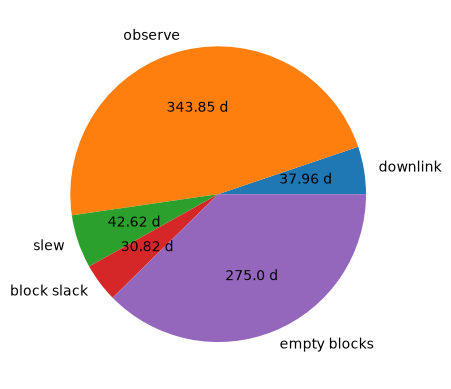

In [6]:
if SAVE_TIME_USAGE_PLOT:
    total_time = {
        key: value.to(u.day)
        for key, value in PLAN.meta["total_time"].items()
        if key != "slack"
    }
    for label, (start_days, end_days) in dead_time_intervals.items():
        total_time[label] = np.clip(end_days - start_days, 0, None).sum() * u.day

    action = list(total_time.keys())
    total_time_values = u.Quantity(list(total_time.values()))

    # Write the underlying numbers to disk alongside the plot.
    time_usage_table = QTable(
        {
            "action": action,
            "duration": total_time_values,
            "fraction": (total_time_values / total_time_values.sum()).to(u.percent),
        }
    )
    time_usage_table["fraction"].info.format = "%.2f"
    time_usage_table.write(
        OUTPUT_PATH / "time-utilization.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots()
    ax.pie(
        total_time_values,
        labels=action,
        autopct=lambda pct: (0.01 * pct * total_time_values.sum().to(u.day)).round(2),
    )
    fig.savefig(OUTPUT_PATH / "time-utilization.pdf", metadata={"CreationDate": None})

### Weekly usage breakdown

Break the same time budget (observing, slewing, downlinking, block slack, and empty blocks) down
into weekly bins to see how usage evolves over the course of the survey, rather than only in
aggregate. Each category's constituent intervals are apportioned across every weekly bin they
overlap, so the stacked bars for any fully-covered week sum to 100%.

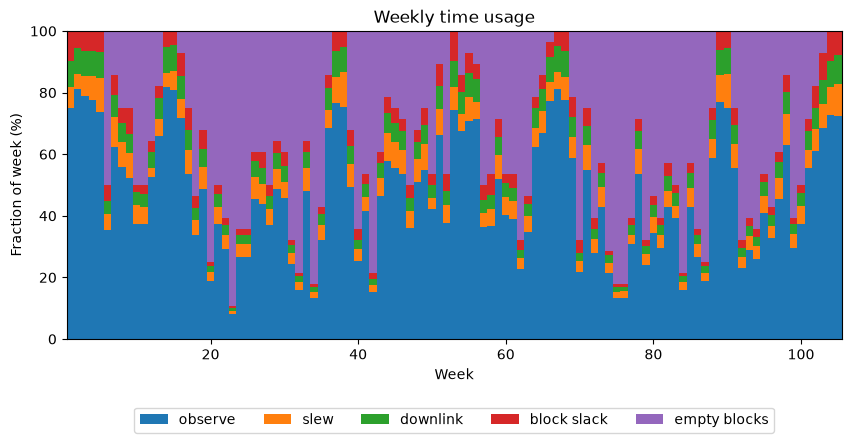

In [7]:
if SAVE_WEEKLY_USAGE_PLOT:

    def _bin_duration(start_days, end_days, edges):
        """Distribute each ``[start, end)`` interval's duration across bins by overlap."""
        n_bins = len(edges) - 1
        result = np.zeros(n_bins)
        keep = end_days > start_days
        start_days, end_days = start_days[keep], end_days[keep]
        i0 = np.clip(
            np.searchsorted(edges, start_days, side="right") - 1, 0, n_bins - 1
        )
        i1 = np.clip(np.searchsorted(edges, end_days, side="right") - 1, 0, n_bins - 1)
        same = i0 == i1
        np.add.at(result, i0[same], (end_days - start_days)[same])
        # A handful of intervals (typically long empty-blocks gaps) straddle a bin edge; split
        # those across every bin they touch instead of crediting them entirely to one bin.
        for s, e, b0, b1 in zip(
            start_days[~same], end_days[~same], i0[~same], i1[~same]
        ):
            for b in range(b0, b1 + 1):
                result[b] += min(e, edges[b + 1]) - max(s, edges[b])
        return result

    n_weeks = int(np.ceil(action_end_days[-1] / 7))
    week_edges = np.arange(n_weeks + 1) * 7.0
    weeks = np.arange(1, n_weeks + 1)

    usage_labels = ["observe", "slew", "downlink", "block slack", "empty blocks"]
    week_usage = {
        label: _bin_duration(
            action_start_days[plan_sorted["action"] == label],
            action_end_days[plan_sorted["action"] == label],
            week_edges,
        )
        for label in usage_labels[:3]
    }
    for label, (start_days, end_days) in dead_time_intervals.items():
        week_usage[label] = _bin_duration(start_days, end_days, week_edges)

    week_total = sum(week_usage.values())
    week_fraction = {
        label: np.divide(
            duration, week_total, out=np.zeros_like(duration), where=week_total > 0
        )
        * 100
        for label, duration in week_usage.items()
    }

    # Write the underlying numbers to disk alongside the plot.
    weekly_usage_table = QTable({"week": weeks})
    for label in usage_labels:
        column = label.replace(" ", "_")
        weekly_usage_table[f"{column}_duration"] = week_usage[label] * u.day
        weekly_usage_table[f"{column}_fraction"] = week_fraction[label] * u.percent
        weekly_usage_table[f"{column}_fraction"].info.format = "%.2f"
    weekly_usage_table.write(
        OUTPUT_PATH / "weekly-usage.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    bottom = np.zeros(n_weeks)
    for label in usage_labels:
        ax.bar(weeks, week_fraction[label], bottom=bottom, width=1.0, label=label)
        bottom += week_fraction[label]
    ax.set_xlabel("Week")
    ax.set_ylabel("Fraction of week (%)")
    ax.set_xlim(weeks[0] - 0.5, weeks[-1] + 0.5)
    ax.set_ylim(0, 100)
    ax.set_title("Weekly time usage")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=5)
    fig.savefig(
        OUTPUT_PATH / "weekly-usage.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

## Sky Coverage

---

For each of the three candidate FOV shapes, compute how many times each HEALPix pixel on the
sky was visited over the course of the plan. The **inscribed circle** is the shape actually
used to tile the sky (see ``fov.ipynb``), so it should show the most uniform coverage; the
bounding rectangle and the true chip footprint are included for comparison, since the chip
footprint (roll-angle-dependent) is what is actually exposed on any given visit.


In [8]:
HPX = HEALPix(nside=HEALPIX_NSIDE, frame=ICRS())

fovs = [BOUNDING_RECTANGLE_FOV, INSCRIBED_CIRCLE_FOV, mission.fov]
fov_names = ["Bounding rectangle", "Inscribed circle", "Chips"]

# Footprint (a list of per-visit HEALPix pixel-index arrays) for each candidate FOV shape, keyed
# by name -- the "Chips" entry is reused below when computing the cadence distribution, since
# that is the footprint that is actually exposed on any given visit.
fov_footprints = {
    name: footprint_healpix(HPX, fov, OBS["target_coord"], OBS["roll"])
    for name, fov in zip(fov_names, tqdm(fovs))
}

# Per-pixel visit count, and (from that) the number of pixels visited exactly N times, for
# each candidate FOV shape. visit_maps is reused below to plot each FOV's visit count
# spatially.
visit_maps = [
    np.bincount(np.concatenate(footprints), minlength=HPX.npix)
    for footprints in fov_footprints.values()
]
visits = [np.bincount(visit_map) for visit_map in visit_maps]
max_visits = max(len(v) for v in visits)
visits = np.stack([np.pad(v, (0, max_visits - len(v))) for v in visits])

 67%|██████▋   | 2/3 [02:54<01:27, 87.24s/it]


### Visit multiplicity

For each candidate FOV shape, the fraction (and, equivalently, the area) of the sky visited
exactly ``N`` times -- the main check that delivered coverage matches what was assumed when the
sky was tiled (see ``fov.ipynb`` and ``skygrid.ipynb``): the **inscribed circle** should show the
most uniform coverage, since it is the shape the tiling was built around.

Fraction and area differ only by a fixed scale factor (``HPX.pixel_area``), so only the fraction
is plotted below; both are written to ``OUTPUT_PATH`` as tables (``visited-fraction.ecsv`` and
``visited-area.ecsv``) for anyone who wants the numbers directly.

In [9]:
# ========================================= #
# Check for Uncovered Sky                   #
# ========================================= #
# The sky grid is tiled around the inscribed circle specifically to guarantee that it (and, a
# fortiori, the bounding rectangle that contains it) leaves no gaps -- so any pixel that shape
# never visits indicates a real problem (a tiling bug or an observability gap), not an expected
# artifact.
for name, row in zip(fov_names, visits):
    uncovered_fraction = row[0] / HPX.npix * 100
    if uncovered_fraction > 0:
        warnings.warn(
            f"{uncovered_fraction:.3f}% of the sky was never visited by the '{name}' FOV -- "
            "this indicates a real coverage gap.",
            stacklevel=2,
        )

/Users/ediggins/Dev/uvex-scheduler/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3823: UserWarning: 5.613% of the sky was never visited by the 'Chips' FOV -- this indicates a real coverage gap.
  exec(code_obj, self.user_global_ns, self.user_ns)


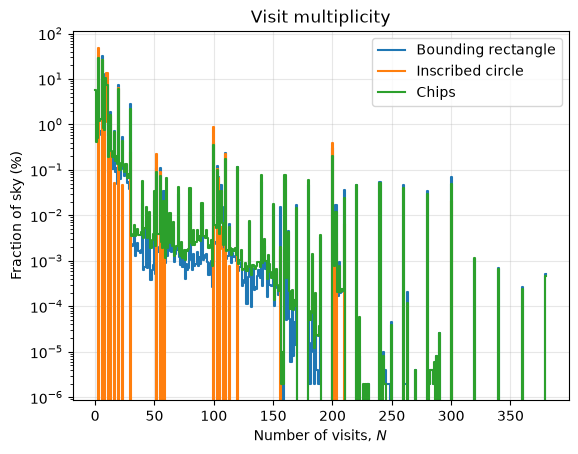

In [10]:
if SAVE_COVERAGE_PLOTS:
    visited_fraction_table = QTable(
        {
            "FOV": fov_names,
            **{
                str(i): col
                for i, col in enumerate(visits.T / HPX.npix * 100 * u.percent)
            },
        }
    )
    visited_area_table = QTable(
        {
            "FOV": fov_names,
            **{
                str(i): col
                for i, col in enumerate((visits.T * HPX.pixel_area).to(u.deg**2))
            },
        }
    )
    for table, fmt in ((visited_fraction_table, "%.2f"), (visited_area_table, "%.0f")):
        for colname in table.colnames:
            if colname != "FOV":
                table[colname].info.format = fmt

    # Write the full N-column breakdown to disk -- too wide to usefully display inline.
    visited_fraction_table.write(
        OUTPUT_PATH / "visited-fraction.ecsv", format="ascii.ecsv", overwrite=True
    )
    visited_area_table.write(
        OUTPUT_PATH / "visited-area.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots()
    n_visits = np.arange(visits.shape[1])
    for name, row in zip(fov_names, visits):
        ax.plot(n_visits, row / HPX.npix * 100, drawstyle="steps-mid", label=name)
    ax.set_yscale("log")
    ax.set_xlabel("Number of visits, $N$")
    ax.set_ylabel("Fraction of sky (%)")
    ax.set_title("Visit multiplicity")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.savefig(
        OUTPUT_PATH / "visit-multiplicity.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

### Visit map

The visit-multiplicity plot above answers "what fraction of the sky was visited N times",
but not *where* those pixels are. This renders each candidate FOV shape's per-pixel visit
count directly on the sky, to check that under- or over-visited regions are where they are
expected to be (e.g. concentrated in LMLZ Deep or the Magellanic Clouds) rather than
scattered arbitrarily, which would indicate a scheduling problem. Written to
``OUTPUT_PATH`` as ``visit-map.pdf``.

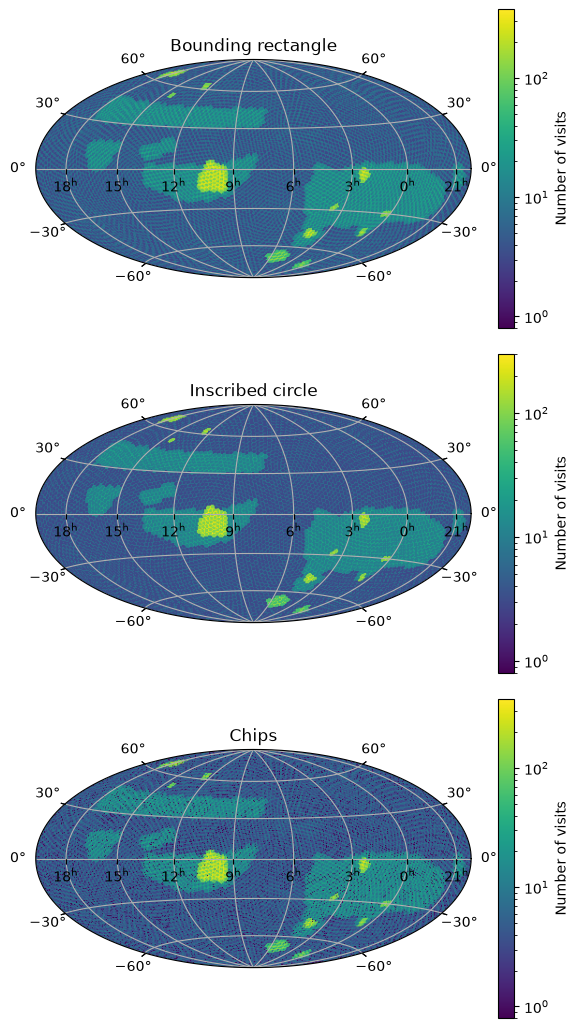

In [11]:
if SAVE_COVERAGE_PLOTS:
    fig, axs = plt.subplots(
        len(fov_names),
        1,
        figsize=(6, 3.5 * len(fov_names)),
        subplot_kw={"projection": "astro aitoff", "center": "8h 0d"},
    )
    for ax, name, visit_map in zip(axs, fov_names, visit_maps):
        im = ax.imshow_hpx(
            visit_map,
            cmap="viridis",
            norm=colors.LogNorm(vmin=0.8, vmax=max(visit_map.max(), 1), clip=True),
        )
        ax.set_title(name)
        ax.grid()
        fig.colorbar(im, ax=ax).set_label("Number of visits")
    fig.tight_layout()
    fig.savefig(
        OUTPUT_PATH / "visit-map.pdf", metadata={"CreationDate": None}, bbox_inches="tight"
    )

### Cumulative visit distribution

The same visit-multiplicity counts as a cumulative distribution: the fraction of the sky visited
**at most** ``N`` times, for each FOV shape. This makes it easy to read off, e.g., what fraction
of the sky falls short of a given cadence requirement, without summing the per-``N`` table by
hand. Written to ``OUTPUT_PATH`` as ``visited-fraction-cdf.ecsv``.

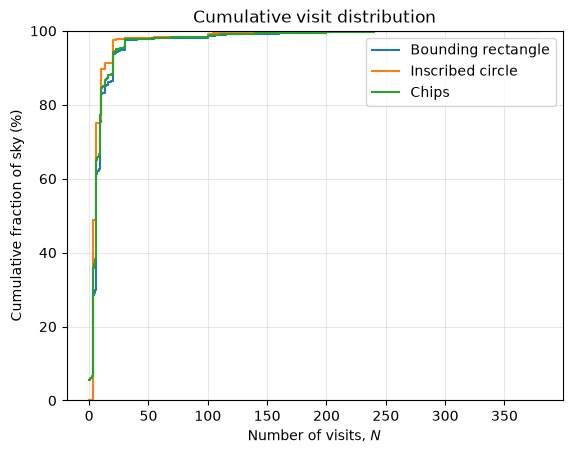

In [12]:
if SAVE_COVERAGE_PLOTS:
    cdf = np.cumsum(visits, axis=1) / HPX.npix * 100

    visited_fraction_cdf_table = QTable(
        {
            "FOV": fov_names,
            **{str(i): col for i, col in enumerate(cdf.T * u.percent)},
        }
    )
    for colname in visited_fraction_cdf_table.colnames:
        if colname != "FOV":
            visited_fraction_cdf_table[colname].info.format = "%.2f"
    visited_fraction_cdf_table.write(
        OUTPUT_PATH / "visited-fraction-cdf.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots()
    for name, row in zip(fov_names, cdf):
        ax.plot(n_visits, row, drawstyle="steps-post", label=name)
    ax.set_xlabel("Number of visits, $N$")
    ax.set_ylabel("Cumulative fraction of sky (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Cumulative visit distribution")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.savefig(
        OUTPUT_PATH / "visit-multiplicity-cdf.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

## Survey Completeness

---

Each block belongs to exactly one constituent survey (``BLOCKS["CATEGORY"]``: ``ALL_SKY_BASE``,
``LMLZ_WIDE``, ``LMLZ_DEEP``, ``LMLZ_DEEP_POINTS``, ``MC``) -- the tier whose cadence requirement
sized it (see ``skyblocks.ipynb``). Observations below are attributed to a survey via each
observation's own ``block_id``, not ``FIELDS["CATEGORY"]`` or the per-field ``OVERLAP_*`` flags:
a single field can overlap several region definitions at once, which would double-count it if
used directly, whereas every field belongs to exactly one block and every block to exactly one
category.

"Required" visits are each category's ``TOTAL_FIELD_VISITS`` (``N_FIELDS * VISITS * DWELLS_PER_VISIT``,
summed over its blocks -- ``DWELLS_PER_VISIT`` is 1 for an ordinary block and
``MAX_DWELLS_PER_BLOCK_NO_SLEW`` for a field-mode LMLZ Deep block, see ``skyblocks.ipynb``'s
"Field-Mode Blocks" section) -- what the block plan actually targets delivering, in the same
units as a count of ``"observe"`` rows, so it's directly comparable to delivered visits with no
separate accounting needed for the padding/rounding captured in ``EXCESS_FIELD_VISITS``.

In [13]:
# ========================================= #
# Attribute Observations to a Survey        #
# ========================================= #
category_by_block_id = np.empty(BLOCKS["BLOCK_ID"].max() + 1, dtype="<U32")
category_by_block_id[np.asarray(BLOCKS["BLOCK_ID"])] = BLOCKS["CATEGORY"]

obs_category = category_by_block_id[np.asarray(OBS["block_id"], dtype=int)]

# Fixed display order, matching the demand-vs-supply breakdown in main.ipynb.
SURVEY_CATEGORIES = ["ALL_SKY_BASE", "LMLZ_WIDE", "LMLZ_DEEP", "LMLZ_DEEP_POINTS", "MC"]

required_visits = {
    category: int(BLOCKS["TOTAL_FIELD_VISITS"][BLOCKS["CATEGORY"] == category].sum())
    for category in SURVEY_CATEGORIES
}

# A fixed, colorblind-safe categorical assignment shared by the table and plot below.
survey_colors = dict(
    zip(SURVEY_CATEGORIES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"])
)

### Visit share

A snapshot, independent of time: what fraction of every delivered observation went to each
constituent survey, and what fraction of that survey's own target has been delivered so far.
Written to ``OUTPUT_PATH`` as ``survey-completeness.ecsv``.

In [14]:
if SAVE_COMPLETENESS_PLOT:
    delivered_visits = {
        category: int(np.sum(obs_category == category))
        for category in SURVEY_CATEGORIES
    }
    total_delivered = sum(delivered_visits.values())

    completeness_table = QTable(
        {
            "category": SURVEY_CATEGORIES,
            "delivered_visits": [delivered_visits[c] for c in SURVEY_CATEGORIES],
            "required_visits": [required_visits[c] for c in SURVEY_CATEGORIES],
            "pct_of_total_visits": [
                delivered_visits[c] / total_delivered * 100 for c in SURVEY_CATEGORIES
            ]
            * u.percent,
            "pct_complete": [
                delivered_visits[c] / required_visits[c] * 100
                for c in SURVEY_CATEGORIES
            ]
            * u.percent,
        }
    )
    for colname in ("pct_of_total_visits", "pct_complete"):
        completeness_table[colname].info.format = "%.2f"
    completeness_table.write(
        OUTPUT_PATH / "survey-completeness.ecsv", format="ascii.ecsv", overwrite=True
    )
    display(completeness_table)

category,delivered_visits,required_visits,pct_of_total_visits,pct_complete
,,,%,%
str16,int64,int64,float64,float64
ALL_SKY_BASE,12534,12534,37.97,100.00
LMLZ_WIDE,11340,11340,34.35,100.00
LMLZ_DEEP,7000,7000,21.21,100.00
LMLZ_DEEP_POINTS,1200,1200,3.64,100.00
MC,936,936,2.84,100.00


### Completeness over time

Cumulative delivered visits by category, as a percentage of that category's own target (from
"Visit share" above), in weekly bins -- how each constituent survey's completion has tracked
over the course of the mission, not just where it stands now. Written to ``OUTPUT_PATH`` as
``survey-completeness-over-time.ecsv``.

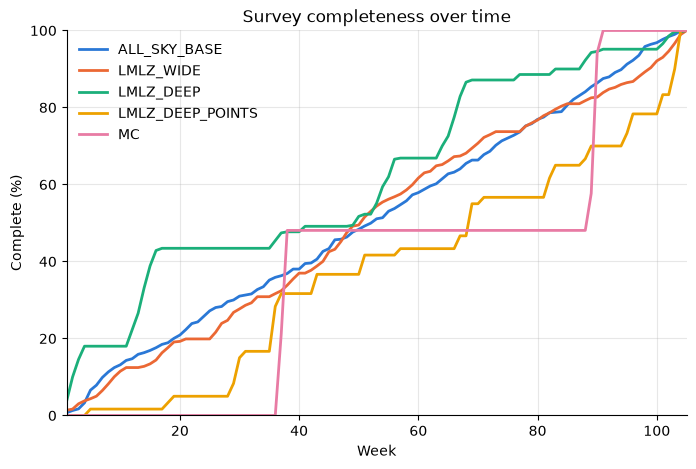

In [15]:
if SAVE_COMPLETENESS_PLOT:
    completeness_t0 = PLAN["start_time"][0]
    obs_elapsed_days = (OBS["start_time"] - completeness_t0).jd

    n_weeks = int(np.ceil(obs_elapsed_days.max() / 7))
    week_edges = np.arange(n_weeks + 1) * 7.0
    weeks = np.arange(1, n_weeks + 1)

    completeness_over_time_table = QTable({"week": weeks})

    fig, ax = plt.subplots(figsize=(8, 5))
    for category in SURVEY_CATEGORIES:
        weekly_counts, _ = np.histogram(
            obs_elapsed_days[obs_category == category], bins=week_edges
        )
        cumulative_pct = np.cumsum(weekly_counts) / required_visits[category] * 100
        completeness_over_time_table[category] = cumulative_pct * u.percent
        ax.plot(
            weeks,
            cumulative_pct,
            color=survey_colors[category],
            linewidth=2,
            label=category,
        )

    ax.set_xlabel("Week")
    ax.set_ylabel("Complete (%)")
    ax.set_ylim(0, 100)
    ax.set_xlim(weeks[0], weeks[-1])
    ax.set_title("Survey completeness over time")
    ax.legend(frameon=False, loc="upper left")
    ax.grid(alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    fig.savefig(
        OUTPUT_PATH / "survey-completeness-over-time.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

    completeness_over_time_table.write(
        OUTPUT_PATH / "survey-completeness-over-time.ecsv",
        format="ascii.ecsv",
        overwrite=True,
    )

## Cadence Distribution

---

Cadence is fundamentally about *pairs* of observations of the same point on the sky, but scanning
every pair of *visits* anywhere on the sky -- as an earlier version of this section did, via
``itertools.combinations`` over the whole observation list -- is O(N_visits^2): for a multi-year,
many-pass survey with tens of thousands of visits, that is billions of pairs, and runs out of
memory before it finishes.

The fix is to only ever compare visits that could plausibly be paired in the first place, i.e.
visits of the *same* point on the sky. Binning every observation's rolled footprint onto a
coarse HEALPix grid (``CADENCE_HEALPIX_NSIDE``) turns the global all-pairs scan into a per-pixel
one, and a per-pixel all-pairs scan stays cheap even as the survey revisits the sky many times
over, since it only ever has to search among that one pixel's own (typically modest) visit count.
This is the same technique used by the predecessor ``uvex-survey-simulations`` repo's
``uvex_transients.surveys.base.SurveySchedule`` cadence utilities, ported here directly since
this notebook has no dependency on that (now superseded) package.

In [16]:
# ========================================= #
# Bin Visits by Pixel for Cadence           #
# ========================================= #
# Rasterizes every "observe" action's rolled footprint onto CADENCE_HEALPIX_NSIDE (much coarser
# than the coverage grid above) and groups the resulting per-pixel visit times into a CSR-style
# layout: visit_times[cadence_offsets[i]:cadence_offsets[i + 1]] gives pixel i's sorted elapsed
# visit times (in days since the first observation). Every diagnostic below is then an all-pairs
# scan *within* one pixel's own visits, rather than across the whole observation list.
CADENCE_HPX = HEALPix(nside=CADENCE_HEALPIX_NSIDE, frame=ICRS())

cadence_footprints = footprint_healpix(
    CADENCE_HPX, mission.fov, OBS["target_coord"], OBS["roll"]
)
cadence_pixels = np.concatenate(cadence_footprints)

cadence_t0 = OBS["start_time"][0]
elapsed_days = (OBS["start_time"] - cadence_t0).jd
visit_times = np.repeat(
    elapsed_days, [len(pixel_ids) for pixel_ids in cadence_footprints]
)

# Group entries by pixel; OBS (and hence visit_times) is already chronological, and a stable
# sort preserves that order within each pixel's group.
sort_idx = np.argsort(cadence_pixels, kind="stable")
cadence_pixels = cadence_pixels[sort_idx]
visit_times = visit_times[sort_idx]

cadence_visit_counts = np.bincount(cadence_pixels, minlength=CADENCE_HPX.npix)
cadence_offsets = np.empty(CADENCE_HPX.npix + 1, dtype=np.int64)
cadence_offsets[0] = 0
np.cumsum(cadence_visit_counts, out=cadence_offsets[1:])


def _pixel_pair_count(times, lo, hi):
    """
    Count one pixel's own visit pairs with separation in ``[lo, hi]``.

    Uses two vectorized ``numpy.searchsorted`` calls (one query per visit, all evaluated at
    once) rather than materializing every pairwise difference, so this stays O(n log n) in the
    number of visits to this one pixel, regardless of how many times the survey has revisited
    it overall.
    """
    if len(times) < 2:
        return 0

    lo_idx = np.searchsorted(times, times - hi, side="left")
    hi_idx = np.searchsorted(times, times - lo, side="right")
    hi_idx = np.minimum(hi_idx, np.arange(len(times)))

    return int(np.sum(np.maximum(hi_idx - lo_idx, 0)))

### Cadence pair-separation histogram

Every unique pairwise time separation between two observations of the same pixel, log-binned and
weighted by that pixel's area -- built from only the within-pixel pairs the binning above
produces, rather than every pair of visits anywhere on the sky. A pixel revisited many times
contributes to several bins (once per qualifying pair), so this measures how much *observing
effort* went into each cadence, not a deduplicated sky area (contrast the pair-count sensitivity
curve below, which does deduplicate). The bin range is set from the survey's own minimum and
maximum pairwise separations -- found cheaply from each pixel's *adjacent*-visit gaps and total
visit span, without materializing any pairs -- before the (still small per pixel, but numerous)
full pairwise histogramming pass runs. Written to ``OUTPUT_PATH`` as ``cadence-histogram.ecsv``.

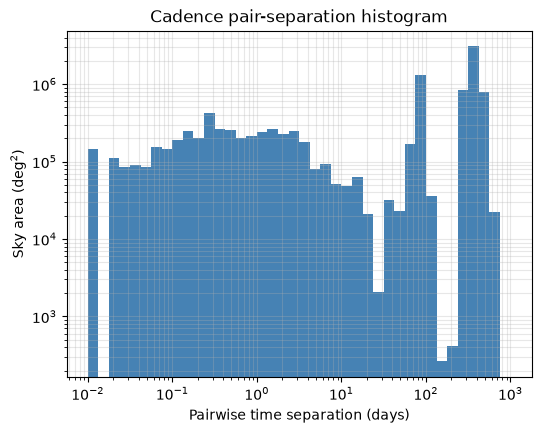

In [17]:
if SAVE_CADENCE_PLOTS:
    occupied_pixels = np.flatnonzero(cadence_visit_counts >= 2)

    # Cheap first pass: for a sorted set of visit times, the minimum pairwise separation is
    # always between two chronologically adjacent visits, and the maximum is always between the
    # first and last -- so the full bin range can be found without materializing any pairs.
    min_separation = np.inf
    max_separation = 0.0
    for pixel in occupied_pixels:
        times = visit_times[cadence_offsets[pixel] : cadence_offsets[pixel + 1]]
        gaps = np.diff(times)
        gaps = gaps[gaps > 0]
        if len(gaps):
            min_separation = min(min_separation, gaps.min())
        max_separation = max(max_separation, times[-1] - times[0])

    hist_edges = np.logspace(
        np.floor(np.log10(min_separation)),
        np.ceil(np.log10(max_separation)),
        CADENCE_N_HISTOGRAM_BINS + 1,
    )
    pixel_area_deg2 = CADENCE_HPX.pixel_area.to_value(u.deg**2)

    # Second pass: accumulate each pixel's own (small) set of pairwise separations into the
    # shared histogram immediately, rather than concatenating every pixel's pairs into one array
    # first -- this bounds peak memory use by the single largest pixel's pair count, not the
    # survey-wide total (which can run into the hundreds of millions for a multi-year, many-pass
    # survey).
    pair_area_histogram = np.zeros(CADENCE_N_HISTOGRAM_BINS)
    for pixel in occupied_pixels:
        times = visit_times[cadence_offsets[pixel] : cadence_offsets[pixel + 1]]
        i, j = np.triu_indices(len(times), k=1)
        counts, _ = np.histogram(times[j] - times[i], bins=hist_edges)
        pair_area_histogram += counts

    pair_area_histogram *= pixel_area_deg2

    cadence_histogram_table = QTable(
        {
            "bin_start": hist_edges[:-1] * u.day,
            "bin_end": hist_edges[1:] * u.day,
            "area": pair_area_histogram * u.deg**2,
        }
    )
    cadence_histogram_table.write(
        OUTPUT_PATH / "cadence-histogram.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.stairs(pair_area_histogram, hist_edges, fill=True, color="steelblue")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Pairwise time separation (days)")
    ax.set_ylabel("Sky area (deg$^2$)")
    ax.set_title("Cadence pair-separation histogram")
    ax.grid(which="both", alpha=0.3)
    fig.savefig(
        OUTPUT_PATH / "cadence-histogram.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

### Pair-count sensitivity curve

Answers a simple existence question at each transient timescale $T$: is there *any* pair of
observations of a given pixel separated by roughly $T$ (specifically
``CADENCE_MINIMUM_FACTOR * T`` to ``CADENCE_MAXIMUM_FACTOR * T``), i.e. could this survey ever
catch a timescale-$T$ transient rising or fading there? Summing solid angle over pixels with at
least one qualifying pair gives the total sky area with any cadence sensitivity to $T$ -- the
same idea behind LSST/Rubin's ``PairMetric``. Written to ``OUTPUT_PATH`` as
``pair-count-curve.ecsv``.

Pair-count sensitivity curve: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]


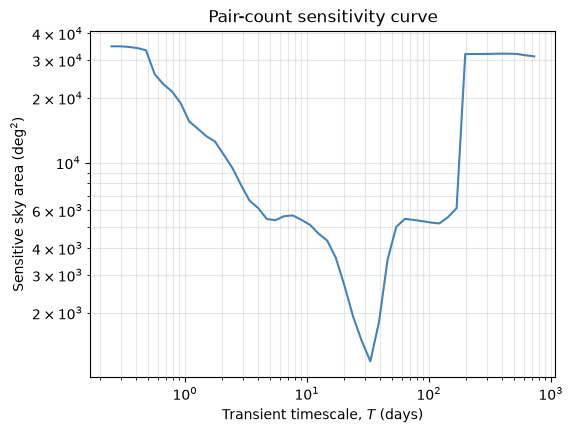

In [18]:
if SAVE_CADENCE_PLOTS:
    timescales = (
        np.geomspace(
            CADENCE_MIN_TIMESCALE.to_value(u.day),
            CADENCE_MAX_TIMESCALE.to_value(u.day),
            CADENCE_N_TIMESCALES,
        )
        * u.day
    )

    # Only pixels with at least two visits can ever contain a qualifying pair; the (expensive)
    # per-pixel visit times were already computed once above and are reused for every timescale.
    observed_pixels = np.flatnonzero(cadence_visit_counts >= 2)
    pixel_area = CADENCE_HPX.pixel_area

    sensitive_area = np.zeros(len(timescales))
    for k, timescale in enumerate(
        tqdm(timescales, desc="Pair-count sensitivity curve")
    ):
        lo = (CADENCE_MINIMUM_FACTOR * timescale).to_value(u.day)
        hi = (CADENCE_MAXIMUM_FACTOR * timescale).to_value(u.day)

        n_sensitive = 0
        for pixel in observed_pixels:
            times = visit_times[cadence_offsets[pixel] : cadence_offsets[pixel + 1]]
            if _pixel_pair_count(times, lo, hi) > 0:
                n_sensitive += 1

        sensitive_area[k] = n_sensitive * pixel_area.to_value(u.deg**2)

    pair_count_table = QTable(
        {"timescale": timescales, "sensitive_area": sensitive_area * u.deg**2}
    )
    pair_count_table.write(
        OUTPUT_PATH / "pair-count-curve.ecsv", format="ascii.ecsv", overwrite=True
    )

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.loglog(timescales.to_value(u.day), sensitive_area, color="steelblue")
    ax.set_xlabel("Transient timescale, $T$ (days)")
    ax.set_ylabel("Sensitive sky area (deg$^2$)")
    ax.set_title("Pair-count sensitivity curve")
    ax.grid(which="both", alpha=0.3)
    fig.savefig(
        OUTPUT_PATH / "pair-count-curve.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

## Slew Distribution

---

Slews immediately before or after a downlink are unconstrained -- the instrument returns to a
fixed downlink orientation, so a large slew (or a `nominal_roll` discontinuity) there is not a
concern -- so they are broken out from ordinary observing slews, which are typically much
smaller (see the roll-angle discussion in ``main.ipynb``). Every slew is also counted once more
under "All slews", as a baseline for comparison.

Both the slew's angular size and how long it actually takes are shown below, since the two
aren't simply proportional: ``mission.slew``'s angular-motion profile has separate accel/cruise/
settle phases, so short slews are dominated by fixed overhead while only long slews are actually
cruise-limited.

In [19]:
# ========================================= #
# Classify Slews                            #
# ========================================= #
is_slew = PLAN["action"] == "slew"

# A slew is adjacent to a downlink if the action immediately before or after it is a downlink.
# Shifted boolean comparisons (rather than slicing PLAN[:-2]/PLAN[2:]) so a slew at either end of
# the table is still classified correctly instead of being silently dropped.
is_downlink_slew = np.zeros(len(PLAN), dtype=bool)
is_downlink_slew[1:] |= PLAN["action"][:-1] == "downlink"
is_downlink_slew[:-1] |= PLAN["action"][1:] == "downlink"
is_downlink_slew &= is_slew

slew_groups = {
    "All slews": is_slew,
    "Observing slews": is_slew & ~is_downlink_slew,
    "Downlink slews": is_downlink_slew,
}

slew_durations = {
    name: PLAN["duration"][mask].to(u.minute) for name, mask in slew_groups.items()
}
slew_angles = {
    name: PLAN["slew_angle"][mask].filled(np.nan) for name, mask in slew_groups.items()
}

# A fixed, colorblind-safe categorical assignment shared by both plots below, so "All slews" is
# always blue, "Observing slews" always orange, "Downlink slews" always aqua.
slew_colors = {
    "All slews": "#2a78d6",
    "Observing slews": "#eb6834",
    "Downlink slews": "#1baf7a",
}

### Slew duration

How long each slew actually takes, for all slews together and for each category separately,
overlaid on one plot with a shared set of bins (spanning the full range of "All slews") so the
three are directly comparable. Written to ``OUTPUT_PATH`` as ``slew-duration-distribution.ecsv``.

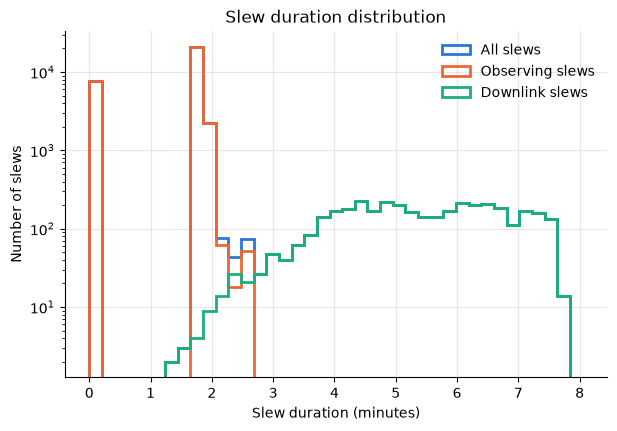

In [20]:
if SAVE_SLEW_DISTRIBUTION_PLOT:
    duration_bins = np.linspace(
        0, slew_durations["All slews"].to_value(u.minute).max() * 1.05, 40
    )

    slew_duration_table = QTable(
        {
            "bin_start": duration_bins[:-1] * u.minute,
            "bin_end": duration_bins[1:] * u.minute,
        }
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for name, durations in slew_durations.items():
        counts, _, _ = ax.hist(
            durations.to_value(u.minute),
            bins=duration_bins,
            histtype="step",
            linewidth=2,
            color=slew_colors[name],
            label=name,
        )
        slew_duration_table[name.replace(" ", "_")] = counts
    ax.set_yscale("log")
    ax.set_xlabel("Slew duration (minutes)")
    ax.set_ylabel("Number of slews")
    ax.set_title("Slew duration distribution")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    fig.savefig(
        OUTPUT_PATH / "slew-duration-distribution.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

    slew_duration_table.write(
        OUTPUT_PATH / "slew-duration-distribution.ecsv",
        format="ascii.ecsv",
        overwrite=True,
    )

### Slew angle

The angular size of each slew, on the same three-way split, overlaid on one plot with a shared
set of bins. Written to ``OUTPUT_PATH`` as ``slew-angle-distribution.ecsv``.

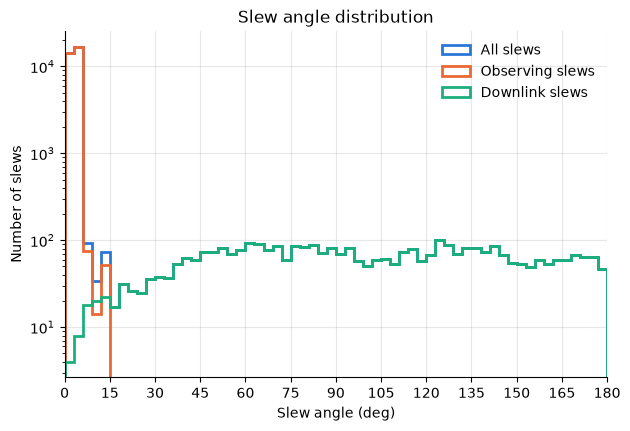

In [21]:
if SAVE_SLEW_DISTRIBUTION_PLOT:
    angle_bins = np.arange(0, 181, 3)

    slew_angle_table = QTable(
        {"bin_start": angle_bins[:-1] * u.deg, "bin_end": angle_bins[1:] * u.deg}
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for name, angles in slew_angles.items():
        counts, _, _ = ax.hist(
            angles.to_value(u.deg),
            bins=angle_bins,
            histtype="step",
            linewidth=2,
            color=slew_colors[name],
            label=name,
        )
        slew_angle_table[name.replace(" ", "_")] = counts
    ax.set_yscale("log")
    ax.set_xlabel("Slew angle (deg)")
    ax.set_ylabel("Number of slews")
    ax.set_xlim(0, 180)
    ax.xaxis.set_major_locator(plt.MultipleLocator(15))
    ax.set_title("Slew angle distribution")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    fig.savefig(
        OUTPUT_PATH / "slew-angle-distribution.pdf",
        metadata={"CreationDate": None},
        bbox_inches="tight",
    )

    slew_angle_table.write(
        OUTPUT_PATH / "slew-angle-distribution.ecsv",
        format="ascii.ecsv",
        overwrite=True,
    )